In [2]:
# Imports
import string
import numpy as np
import pandas as pd
from IPython.display import display, HTML

# Increase the width of the notebook for displaying DataFrames
display(HTML("<style>.container { width:75% !important; }</style>"))

In [5]:
#Load dataset
df = pd.read_csv("data.csv", low_memory=False)

In [7]:
df.head()

,Id,Title,Company,Date,Location,Area,Classification,SubClassification,Requirement,FullDescription,LowestSalary,HighestSalary,JobType
0,37404348,Casual Stock Replenisher,Aldi Stores,2018-10-07T00:00:00.000Z,Sydney,North West & Hills District,Retail & Consumer Products,Retail Assistants,Our Casual Stock Replenishers pride themselves...,NaN,0,30,NaN
1,37404337,Casual Stock Replenisher,Aldi Stores,2018-10-07T00:00:00.000Z,Richmond & Hawkesbury,NaN,Retail & Consumer Products,Retail Assistants,Our Casual Stock Replenishers pride themselves...,NaN,0,30,NaN
2,37404356,RETAIL SALES SUPERSTARS and STYLISTS Wanted - ...,LB Creative Pty Ltd,2018-10-07T00:00:00.000Z,Brisbane,CBD & Inner Suburbs,Retail & Consumer Products,Retail Assistants,BRAND NEW FLAGSHIP STORE OPENING - SUNSHINE PLAZA,NaN,0,30,NaN
3,37404330,Team member - Belrose,Anaconda Group Pty Ltd,2018-10-07T00:00:00.000Z,Gosford & Central Coast,NaN,Retail & Consumer Products,Retail Assistants,Bring it on - do you love the great outdoors a...,NaN,0,30,NaN
4,37404308,"Business Banking Contact Centre Specialist, Ni...",Commonwealth Bank - Business & Private Banking,2018-10-07T00:00:00.000Z,Sydney,Ryde & Macquarie Park,Call Centre & Customer Service,Sales - Inbound,"We are seeking highly articulate, enthusiastic...",NaN,0,30,NaN


Part 1 - Data Preparation and Preprocessing
1. Describe the Dataset

Describe the dataset (e.g.: type of column, value range)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318477 entries, 0 to 318476
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 318477 non-null  object
 1   Title              318477 non-null  object
 2   Company            306473 non-null  object
 3   Date               318477 non-null  object
 4   Location           197229 non-null  object
 5   Area               122658 non-null  object
 6   Classification     197229 non-null  object
 7   SubClassification  197229 non-null  object
 8   Requirement        318470 non-null  object
 9   FullDescription    302302 non-null  object
 10  LowestSalary       318477 non-null  int64 
 11  HighestSalary      318477 non-null  int64 
 12  JobType            302379 non-null  object
dtypes: int64(2), object(11)
memory usage: 31.6+ MB


In [9]:
df.describe()

,LowestSalary,HighestSalary
count,318477.000000,318477.000000
mean,65.813544,114.432342
std,51.063125,177.594941
min,0.000000,30.000000
25%,30.000000,40.000000
50%,60.000000,70.000000
75%,100.000000,120.000000
max,200.000000,999.000000


The dataset has 13 columns and 318477 rows or job postings. This data is from seek.com.
Columns Company, Location, Area, Classification, SubClasssification and JobType are Categorical.
Date is a timestamp.
LowestSalary and HighestSalary are Numerical.
Id is Text/string or Categorical.
Title, Requirement and FullDescription are Text/String.
From df.describe() Salaries range from 0-300.

How many records are there in the dataset? 

In [10]:
len(df)

318477

Which period does it cover? How many different dates have job postings?

In [11]:
dates = df.sort_values('Date')['Date'].dropna().unique()
start_date = dates[0]
end_date = dates[-1]

print("Start Date:", start_date)
print("End Date:", end_date)
print("Number of dates:", len(dates))

Start Date: 2018-10-01T00:00:00.000Z
End Date: 2019-03-13T00:00:00.000Z
Number of dates: 163


The dataset covers the period October 1st, 2018 to March 13th 2019. 163 dates have job postings.

How many locations does the dataset have? Which location has the most job
postings?

In [12]:
df['Location'].nunique(), df['Location'].value_counts().idxmax()

(65, 'Sydney')

There are 65 unique locations in the dataset and Sydney has the largest number of job postings.

How many job sectors(job classifications) are there in the dataset? List the name of
each sector and its’ total of job postings.

In [13]:
classification_counts = df['Classification'].value_counts()
classification_counts

Classification
Information & Communication Technology    22796
Trades & Services                         17976
Healthcare & Medical                      17085
Hospitality & Tourism                     15523
Manufacturing, Transport & Logistics      12376
Administration & Office Support           10020
Accounting                                 9368
Education & Training                       9280
Construction                               8372
Sales                                      8119
Retail & Consumer Products                 8041
Government & Defence                       7443
Engineering                                6458
Mining, Resources & Energy                 6288
Banking & Financial Services               4633
Community Services & Development           4485
Legal                                      4237
Human Resources & Recruitment              4144
Call Centre & Customer Service             3971
Marketing & Communications                 3968
Real Estate & Property   

There are 30 job sectors in the data.

Choose your favorite job sector (e.g. Information & Communication Technology),
how many sub-sectors are there in that sector? List the name of each sub-sector and its’ job posting number

In [14]:
sport_df = df[df['Classification'] == 'Sport & Recreation']
sport_sub_counts = sport_df['SubClassification'].value_counts()
sport_sub_counts

SubClassification
Fitness & Personal Training    406
Other                          221
Coaching & Instruction         179
Management                     178
Name: count, dtype: int64

My favourite chosen job sector was Sport and Recreation. There are 4 sub-sectros.

List the salary ranges and their total of job postings.

In [15]:
salary_ranges = df.groupby(['LowestSalary', 'HighestSalary']).size().reset_index(name='Count')
salary_ranges

,LowestSalary,HighestSalary,Count
0,0,30,62639
1,30,40,23476
2,40,50,34436
3,50,60,27027
4,60,70,28499
5,70,80,28712
6,80,100,24249
7,100,120,27673
8,120,150,24514
9,150,200,25841


There are 11 salary ranges in the dataset.

List the job types. In each job type, what are the lowest salary and highest salary?

In [16]:
df.groupby('JobType')[['LowestSalary', 'HighestSalary']].agg(['min', 'max'])

LowestSalary      HighestSalary     
                         min  max           min  max
JobType                                             
Casual/Vacation            0  200            30  999
Contract/Temp              0  200            30  999
Full Time                  0  200            30  999
Part Time                  0  200            30  999

There are 4 job types.

2. Normalize and clean data.

The salaries are kept in the dataset as “HighestSalary” and “LowestSalary”. You
should calculate the “AverageSalary” for each job

In [49]:
df['AverageSalary'] = (df['LowestSalary'] + df['HighestSalary']) / 2

The raw dataset values of the "Id" column had inconsistencies in their
representation. The Id values should have 8 number long integers only. Write code
to remove unnecessary characters.

In [50]:
df['Id'] = df['Id'].astype(str).str.extract(r'(\d{8})') 
df['Id'] = pd.to_numeric(df['Id'])

The "Date" column is represented in a format that contained both date and time
information. However, the time is not correct and should be removed

In [51]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'] = df['Date'].dt.date

Change type of “Id” column to numeric and change type of “Date” column to
DateTime. 

In [52]:
df['Id'] = pd.to_numeric(df['Id'])
df['Date'] = pd.to_datetime(df['Date'])

In [24]:
df.dtypes

Id                            int64
Title                        object
Company                      object
Date                 datetime64[ns]
Location                     object
Area                         object
Classification               object
SubClassification            object
Requirement                  object
FullDescription              object
LowestSalary                  int64
HighestSalary                 int64
JobType                      object
AverageSalary               float64
dtype: object

In [25]:
duplicate_count = df[df.duplicated()].shape[0]
print("Duplicates found (including Date):", duplicate_count)
no_dates = df.drop('Date', axis=1)
duplicate_count_no_dates = no_dates[no_dates.duplicated()].shape[0]
difference = duplicate_count_no_dates - duplicate_count
print("Additional duplicates found without regard to date:", difference)

Duplicates found (including Date): 108
Additional duplicates found without regard to date: 43


108 duplicate job postings were found includuing the Date. When ignoring the Date cloumn an additional 43 duplicates were found.This makes sure the same jobs posted on different dates are also indetified.

In [26]:
df = df.drop_duplicates()

My solution was to remove only exact duplicates

Check missing data and visualize them in a corresponding chart.**

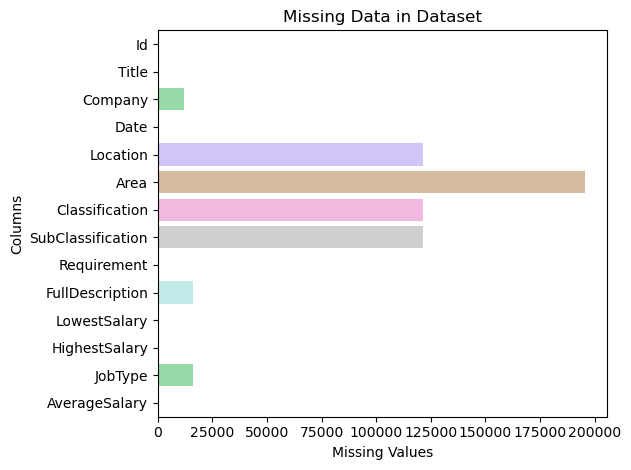

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

missing_counts = df.isnull().sum()
#missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=True)

sns.barplot(
    x=missing_counts.values,
    y=missing_counts.index,
    hue=missing_counts.index,
    palette="pastel",
    legend=False
)
plt.title('Missing Data in Dataset')
plt.xlabel('Missing Values')
plt.ylabel('Columns')
plt.tight_layout()
plt.show()

The bar chart shows there are many columns with missing data. The column with the most missing data is Area. Location, Classification and SubClassification also show a similar significant amount of missing data to one another. In contrast Company, FullDescription and Jobtype show relatively smaller amounts of missing data. This chart allows us to assess which attributes may require further investigation to understand the cause of the missing values and how they impact the overall analysis.

Part 2 – Data Understanding

Get the salary ranges using “AverageSalary”, the total jobs of each range and display them in the bar chart. 

In [28]:
#Group by average salary and count the numbers
averageSalaryDf = df.groupby('AverageSalary').count()
averageSalaryDf['AverageSalary'] = (averageSalaryDf.index*1000).astype(float).map('{:,.0f}'.format)
averageSalaryDf['Count'] = averageSalaryDf["Id"]
averageSalaryDf

,Id,Title,Company,Date,Location,Area,Classification,SubClassification,Requirement,FullDescription,LowestSalary,HighestSalary,JobType,AverageSalary,Count
AverageSalary,,,,,,,,,,,,,,,
15.0,62586,62586,59564,62586,38488,24364,38488,38488,62584,56043,62586,62586,56058,"15,000",62586
35.0,23471,23471,22292,23471,16391,9809,16391,16391,23471,22091,23471,23471,22093,"35,000",23471
45.0,34431,34431,32071,34431,21731,13259,21731,21731,34430,33575,34431,34431,33580,"45,000",34431
55.0,27018,27018,25670,27018,16552,10746,16552,16552,27017,26197,27018,27018,26213,"55,000",27018
65.0,28495,28495,27286,28495,18117,11390,18117,18117,28495,27542,28495,28495,27564,"65,000",28495
75.0,28706,28706,27788,28706,17047,10451,17047,17047,28706,27664,28706,28706,27668,"75,000",28706
90.0,24249,24249,23625,24249,12701,7562,12701,12701,24248,23587,24249,24249,23590,"90,000",24249
110.0,27669,27669,27146,27669,17133,10571,17133,17133,27667,26678,27669,27669,26679,"110,000",27669
135.0,24506,24506,24157,24506,14693,9476,14693,14693,24506,23602,24506,24506,23604,"135,000",24506


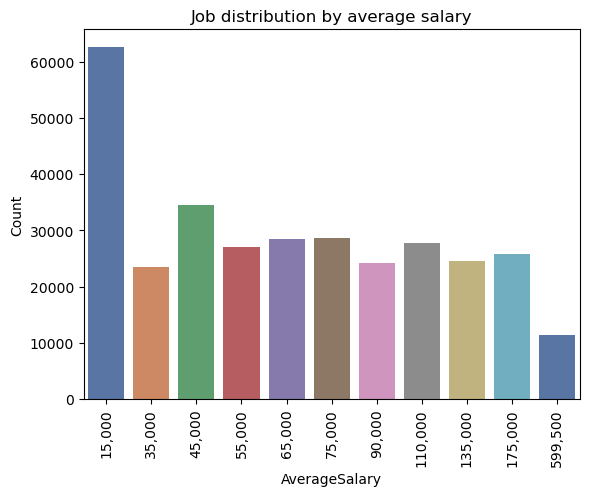

In [30]:
sns.barplot(
    data=averageSalaryDf,
    x="AverageSalary",
    y="Count",
    hue="AverageSalary",
    palette="deep",
    legend=False
)
plt.title("Job distribution by average salary")
plt.xticks(rotation = 90)
plt.show()

Display the list of job types and the number of jobs of each type using pie chart

In [31]:
jobTypeDf = df.groupby("JobType").count()
jobTypeDf['Count'] = jobTypeDf["Id"]
jobTypeDf["JobType"] = jobTypeDf.index
jobTypeDf

,Id,Title,Company,Date,Location,Area,Classification,SubClassification,Requirement,FullDescription,LowestSalary,HighestSalary,AverageSalary,Count,JobType
JobType,,,,,,,,,,,,,,,
Casual/Vacation,25353,25353,23871,25353,16283,8750,16283,16283,25351,25340,25353,25353,25353,25353,Casual/Vacation
Contract/Temp,53897,53897,53076,53897,33953,20871,33953,33953,53897,53892,53897,53897,53897,53897,Contract/Temp
Full Time,201172,201172,192797,201172,122089,77908,122089,122089,201171,201116,201172,201172,201172,201172,Full Time
Part Time,21889,21889,20902,21889,13343,7858,13343,13343,21885,21886,21889,21889,21889,21889,Part Time


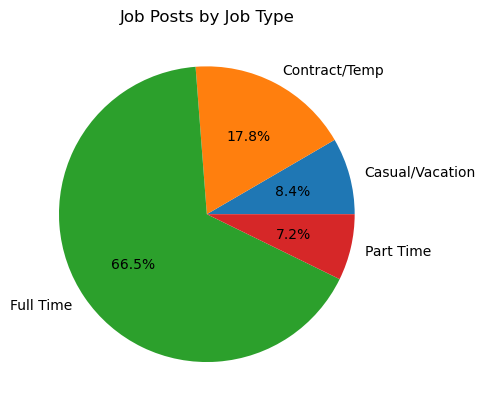

In [32]:
plt.title('Job Posts by Job Type')
plt.pie(jobTypeDf["Count"], labels=jobTypeDf["JobType"], autopct="%1.1f%%")
plt.show()

Display the list of job sectors and the number of jobs of each type using horizontal bar
chart.

In [33]:
classificationDf = df[df['Classification'].isna() == False]
classificationDf = classificationDf.groupby('Classification').count()
classificationDf['Classification'] = classificationDf.index
classificationDf['Count'] = classificationDf['Id']
classificationDf.sort_values("Count", ascending=False, inplace=True)
classificationDf

,Id,Title,Company,Date,Location,Area,SubClassification,Requirement,FullDescription,LowestSalary,HighestSalary,JobType,AverageSalary,Classification,Count
Classification,,,,,,,,,,,,,,,
Information & Communication Technology,22787,22787,22438,22787,22787,16083,22787,22787,21157,22787,22787,21158,22787,Information & Communication Technology,22787
Trades & Services,17966,17966,16492,17966,17966,9664,17966,17966,17119,17966,17966,17120,17966,Trades & Services,17966
Healthcare & Medical,17068,17068,16373,17068,17068,7948,17068,17068,16368,17068,17068,16371,17068,Healthcare & Medical,17068
Hospitality & Tourism,15513,15513,14881,15513,15513,9634,15513,15513,14287,15513,15513,14291,15513,Hospitality & Tourism,15513
"Manufacturing, Transport & Logistics",12372,12372,11461,12372,12372,8542,12372,12372,11748,12372,12372,11750,12372,"Manufacturing, Transport & Logistics",12372
Administration & Office Support,10017,10017,9532,10017,10017,6841,10017,10017,9213,10017,10017,9213,10017,Administration & Office Support,10017
Accounting,9365,9365,9053,9365,9365,7305,9365,9365,8759,9365,9365,8759,9365,Accounting,9365
Education & Training,9272,9272,9030,9272,9272,5864,9272,9272,8711,9272,9272,8715,9272,Education & Training,9272
Construction,8369,8369,8039,8369,8369,5055,8369,8369,8019,8369,8369,8020,8369,Construction,8369


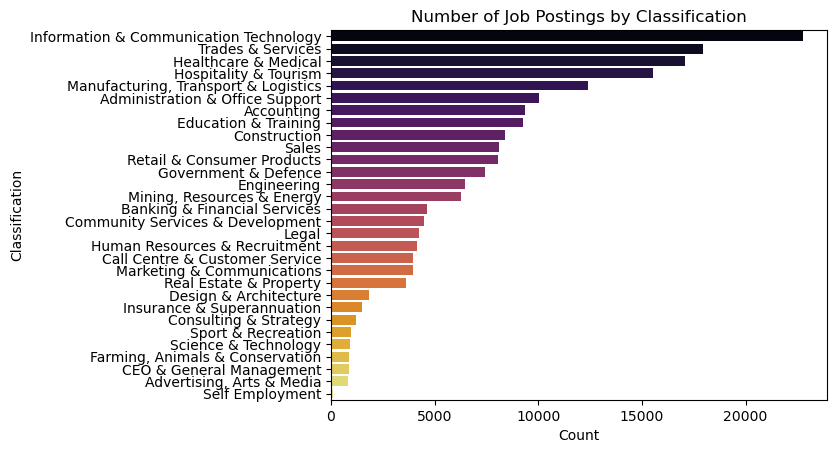

In [34]:
sns.barplot(
    data=classificationDf,
    y="Classification",
    x="Count",
    hue="Classification",
    palette="inferno",
    legend=False
)
plt.title("Number of Job Postings by Classification")
plt.show()

Choose your favorite location. Visualize the market share of that location in pie chart

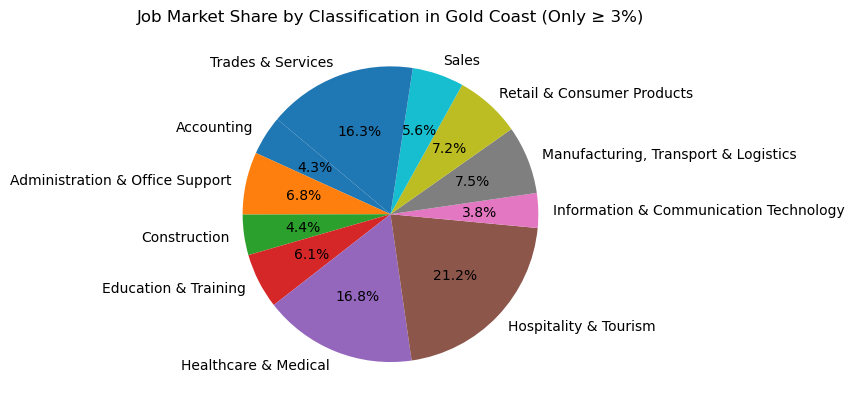

In [35]:
fav_location_df = df[df["Location"] == "Gold Coast"]

fav_classification_df = fav_location_df.groupby("Classification").count()
fav_classification_df["Count"] = fav_classification_df["Id"]
fav_classification_df["Classification"] = fav_classification_df.index

total_jobs = fav_classification_df["Count"].sum()
fav_classification_df["Percentage"] = fav_classification_df["Count"] / total_jobs * 100

# keep only sectors with ≥ 3% of job postings so pie chart isnt clutttered
final_df = fav_classification_df[fav_classification_df["Percentage"] >= 3]

plt.pie(final_df["Count"], labels=final_df["Classification"], autopct='%1.1f%%', startangle=140)
plt.title("Job Market Share by Classification in Gold Coast (Only ≥ 3%)")
plt.show()

Can you find the salary distribution for the top 30 cities for the number of job postings?
Visualize them in the boxplot chart.

In [36]:
locationDf = df[df['Location'].isna() == False]
locationDf = locationDf.groupby('Location').count()
locationDf['Location'] = locationDf.index
locationDf['Count'] = locationDf['Id']
locationDf.sort_values("Count", ascending=False, inplace=True)
locationDf.head()

,Id,Title,Company,Date,Area,Classification,SubClassification,Requirement,FullDescription,LowestSalary,HighestSalary,JobType,AverageSalary,Location,Count
Location,,,,,,,,,,,,,,,
Sydney,60729,60729,58884,60729,53746,60729,60729,60729,57427,60729,60729,57441,60729,Sydney,60729
Melbourne,46656,46656,44907,46656,41268,46656,46656,46652,43804,46656,46656,43810,46656,Melbourne,46656
Brisbane,21455,21455,20601,21455,17403,21455,21455,21455,20207,21455,21455,20214,21455,Brisbane,21455
Perth,13192,13192,12760,13192,10165,13192,13192,13192,12282,13192,13192,12293,13192,Perth,13192
Adelaide,6650,6650,6300,6650,0,6650,6650,6650,6311,6650,6650,6312,6650,Adelaide,6650


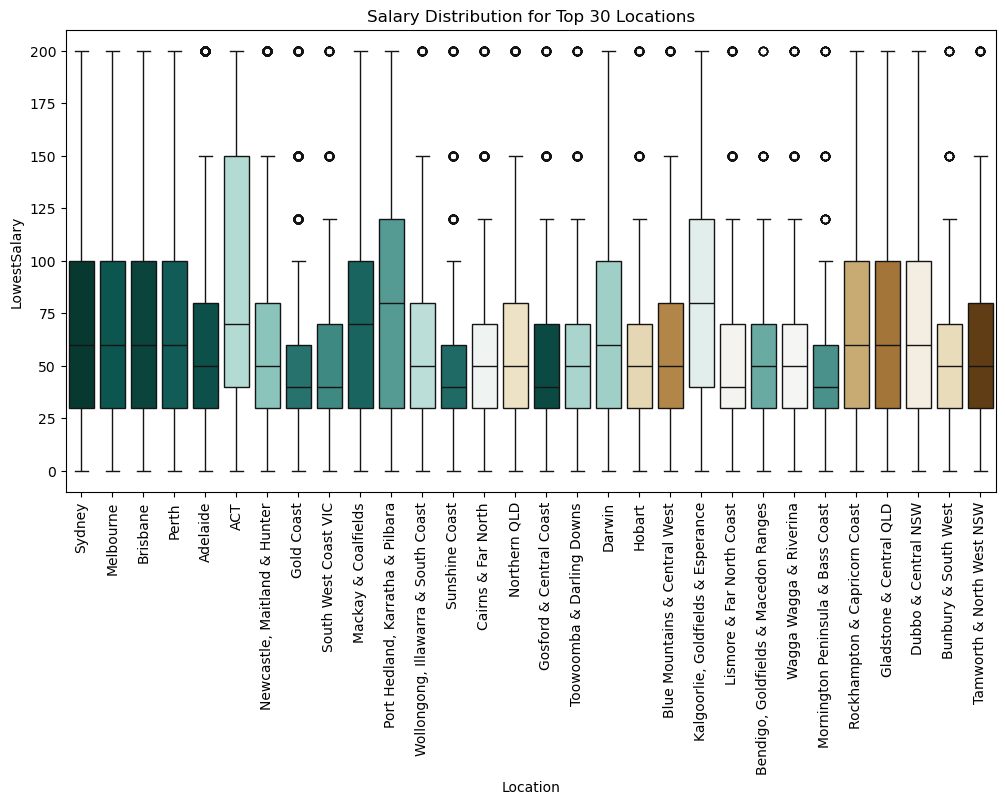

In [38]:
top_30_locations = df["Location"].value_counts().head(30).index

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Location",
    y="LowestSalary",
    order=top_30_locations,
    hue="Location",
    palette="BrBG_r",
    legend=False
)
plt.xticks(rotation=90)
plt.title("Salary Distribution for Top 30 Locations")
plt.show()

Part 3 – Data Analysis and Visualisation.

1. Analyse by comparison.

Choose your two favourite cities/locations. We will explore the difference between
them by answering the following questions:
 Which city has more job? How many jobs each type (casual, fulltime, etc.) are there
in each city?

In [39]:
total_jobs = df["Location"].value_counts()
print(f"Total jobs in Melbourne: {total_jobs["Melbourne"]}")
print(f"Total jobs in Gold Coast: {total_jobs["Gold Coast"]}\n")

job_types_melbourne = df[df["Location"] == "Melbourne"]["JobType"].value_counts()
job_types_goldcoast = df[df["Location"] == "Gold Coast"]["JobType"].value_counts()

print(f"Melbourne job types:\n", job_types_melbourne)
print(f"\nGold Coast job types:\n", job_types_goldcoast)

Total jobs in Melbourne: 46656
Total jobs in Gold Coast: 3587

Melbourne job types:
 JobType
Full Time          29666
Contract/Temp       7208
Part Time           3483
Casual/Vacation     3453
Name: count, dtype: int64

Gold Coast job types:
 JobType
Full Time          2068
Casual/Vacation     621
Contract/Temp       389
Part Time           308
Name: count, dtype: int64


It is evident that Melbourne has many more job posts than Gold Coast. This makes sense as it is a much bigger city. The most common job type in both cities are Full Time jobs.

In each city, which are top 5 job sectors? How many jobs are there in each sector? 

In [40]:
top_sectors_melbourne = df[df["Location"] == "Melbourne"]["Classification"].value_counts().head(5)
top_sectors_goldcoast = df[df["Location"] == "Gold Coast"]["Classification"].value_counts().head(5)
print(f"Top 5 Melbourne job sectors:\n",top_sectors_melbourne)
print(f"\nTop 5 Gold Coast job sectors:\n",top_sectors_goldcoast)

Top 5 Melbourne job sectors:
 Classification
Information & Communication Technology    5888
Hospitality & Tourism                     4057
Trades & Services                         3829
Manufacturing, Transport & Logistics      3555
Healthcare & Medical                      3485
Name: count, dtype: int64

Top 5 Gold Coast job sectors:
 Classification
Hospitality & Tourism                   609
Healthcare & Medical                    481
Trades & Services                       468
Manufacturing, Transport & Logistics    214
Retail & Consumer Products              206
Name: count, dtype: int64


These tables show the top 5 job sectors in each of the chosen cities.They vary quite a bit, for example Melbourne's Top job sector is Information and Communication Technology whildt Gold Coast's top job sector is Hospitality and Tourism.

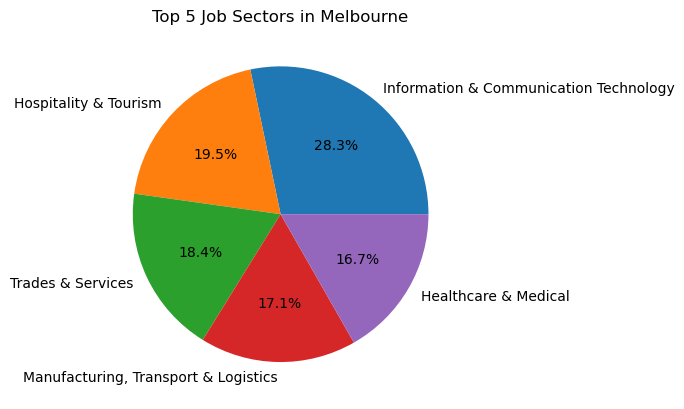

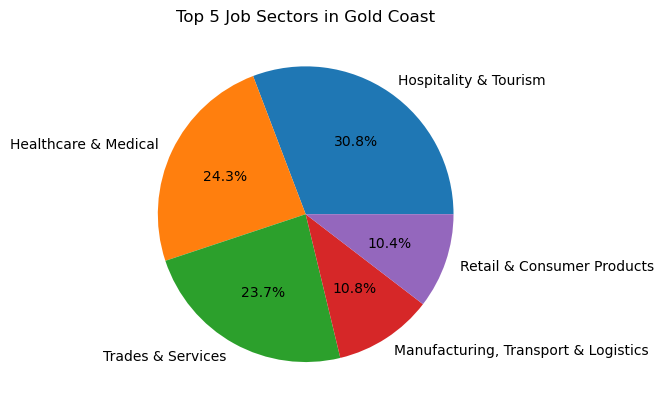

In [41]:
plt.pie(top_sectors_melbourne.values, labels=top_sectors_melbourne.index, autopct='%1.1f%%')
plt.title("Top 5 Job Sectors in Melbourne")
plt.show()

plt.pie(top_sectors_goldcoast.values, labels=top_sectors_goldcoast.index, autopct='%1.1f%%')
plt.title("Top 5 Job Sectors in Gold Coast")
plt.show()

These pie charts again display how Melbourne and Gold Coast top 5 job sectros vary.Job sectros they have in common include Hospitality in Tourism, Manufacturing Transport and Logistics, Trades and Services and Healthcare and Medical. Whilst gold Coast has retail and Cosumer Products in its top 5, and Melbourne has ICT in its top 5. This indicates that Melbourne has much more of a focus on jobs in the ICT industry whilst Gold Coast has alot more retail avaliable.

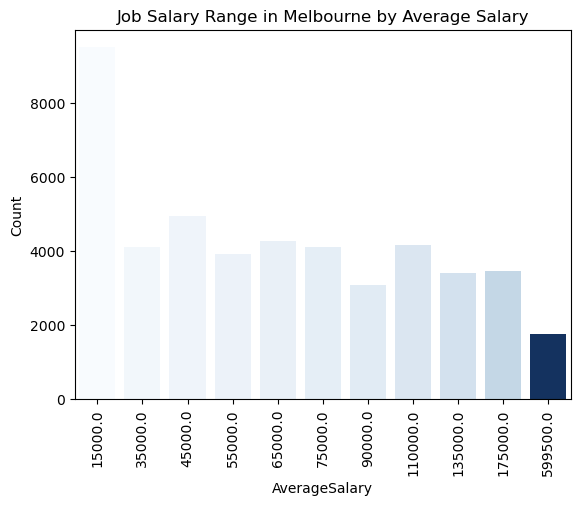

Job Salary Range in Melbourne:
$15,000 : 9493 jobs
$35,000 : 4094 jobs
$45,000 : 4929 jobs
$55,000 : 3926 jobs
$65,000 : 4268 jobs
$75,000 : 4094 jobs
$90,000 : 3084 jobs
$110,000 : 4171 jobs
$135,000 : 3394 jobs
$175,000 : 3448 jobs
$599,500 : 1755 jobs


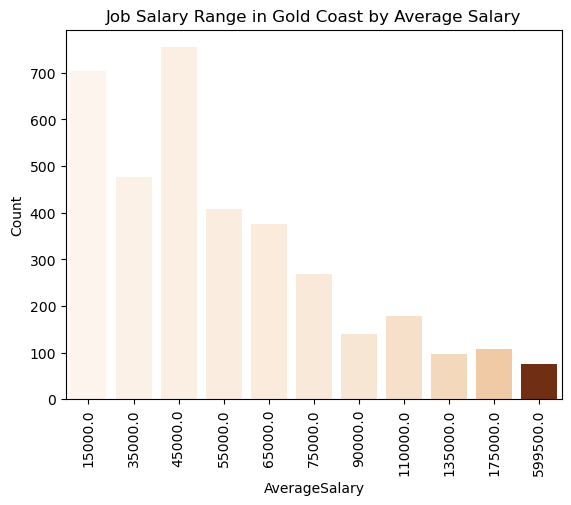


Job Salary Range in Gold Coast:
$15,000 : 703 jobs
$35,000 : 477 jobs
$45,000 : 755 jobs
$55,000 : 408 jobs
$65,000 : 375 jobs
$75,000 : 269 jobs
$90,000 : 140 jobs
$110,000 : 178 jobs
$135,000 : 98 jobs
$175,000 : 108 jobs
$599,500 : 76 jobs


In [43]:
melbourne_df = df[df["Location"] == "Melbourne"]
average_salary_melbourne = melbourne_df.groupby("AverageSalary").count()
average_salary_melbourne["AverageSalary"] = average_salary_melbourne.index*1000
average_salary_melbourne["Count"] = average_salary_melbourne["Id"]

sns.barplot(
    data=average_salary_melbourne,
    x="AverageSalary",
    y="Count",
    hue="AverageSalary",
    palette="Blues",
    legend=False
)
plt.title("Job Salary Range in Melbourne by Average Salary")
plt.xticks(rotation=90)
plt.show()

melb_salary_counts = df[df["Location"] == "Melbourne"]["AverageSalary"].value_counts().sort_index()
print("Job Salary Range in Melbourne:")
for salary, count in melb_salary_counts.items():
    print(f"${int(salary*1000):,} : {count} jobs")

goldcoast_df = df[df["Location"] == "Gold Coast"]
average_salary_goldcoast = goldcoast_df.groupby("AverageSalary").count()
average_salary_goldcoast["AverageSalary"] = average_salary_goldcoast.index*1000
average_salary_goldcoast["Count"] = average_salary_goldcoast["Id"]

sns.barplot(
    data=average_salary_goldcoast,
    x="AverageSalary",
    y="Count",
    hue="AverageSalary",
    palette="Oranges",
    legend=False
)
plt.title("Job Salary Range in Gold Coast by Average Salary")
plt.xticks(rotation=90)
plt.show()

gc_salary_counts = df[df["Location"] == "Gold Coast"]["AverageSalary"].value_counts().sort_index()
print("\nJob Salary Range in Gold Coast:")
for salary, count in gc_salary_counts.items():
    print(f"${int(salary*1000):,} : {count} jobs")

From the above lists and bar charts Melbourne offers a much larger distrbution of jobs in the higher salary brackets compared to the gold coast. Since Melbourne seems to offer more higher paying roles it is the more well paid city. For example Melbourne has 1755 job posts in the 599,500 range compared to the Gold Coast that only has 76 job posts.

List top 5 companies in each city? Which sectors do they belong to?

In [44]:
melbourne_df = df[df["Location"] == "Melbourne"]
top_companies_melbourne = melbourne_df["Company"].value_counts().head(5)

print("Top 5 Companies and Their Main Sector in Melbourne:")
for company in top_companies_melbourne.index:
    company_df = melbourne_df[melbourne_df["Company"] == company]
    main_sector = company_df["Classification"].value_counts().idxmax()
    print(f"{company} : {main_sector}")

goldcoast_df = df[df["Location"] == "Gold Coast"]
top_companies_goldcoast = goldcoast_df["Company"].value_counts().head(5)

print("\nTop 5 Companies and Their Main Sector in Gold Coast:")
for company in top_companies_goldcoast.index:
    company_df = goldcoast_df[goldcoast_df["Company"] == company]
    main_sector = company_df["Classification"].value_counts().idxmax()
    print(f"{company} : {main_sector}")

Top 5 Companies and Their Main Sector in Melbourne:
Jora Local : Hospitality & Tourism
Department of Education & Training Victoria : Education & Training
Design & Build : Construction
Talent – Winner ‘Seek Large Recruitment Agency of the Year’ 3 consecutive years! : Information & Communication Technology
Hays Accountancy & Finance : Accounting

Top 5 Companies and Their Main Sector in Gold Coast:
Jora Local : Hospitality & Tourism
Gold Coast Hospital & Health Service : Government & Defence
Hays Trades & Labour : Trades & Services
Griffith University : Education & Training
City of Gold Coast : Government & Defence


The 2 cities seem to differ quite a bit in terms of their top 5 hiring companies. But they both have the same top hiring company being Jora Local which is apart of the Hospitslity and Tourism Sector. So even though Melbournes top Sector was ICT, the company with the lagest amount of job posts belongs to Hospitality and Tourism.

Between 2 cities, which do you think it is better for employees. Explain your choice.

After comparing Melbourne and Gold Coast across multiple factors like amount oj jobs, salary distrbution, job types, job sectors and top hrirng companies, Melbourne seems to be the better city for employees. Since it had a higher number of job postings across more diverse sectors and a broad variety of job classifications including high demand fields like ICT. Melbourne also has a larger amount of job posts in higher salary brackets indiciating better overall pay for job seekers.

2. Analyse by time.
In this part, we will analyse the jobs based on the posting date.

Visualise the number of job posts by month

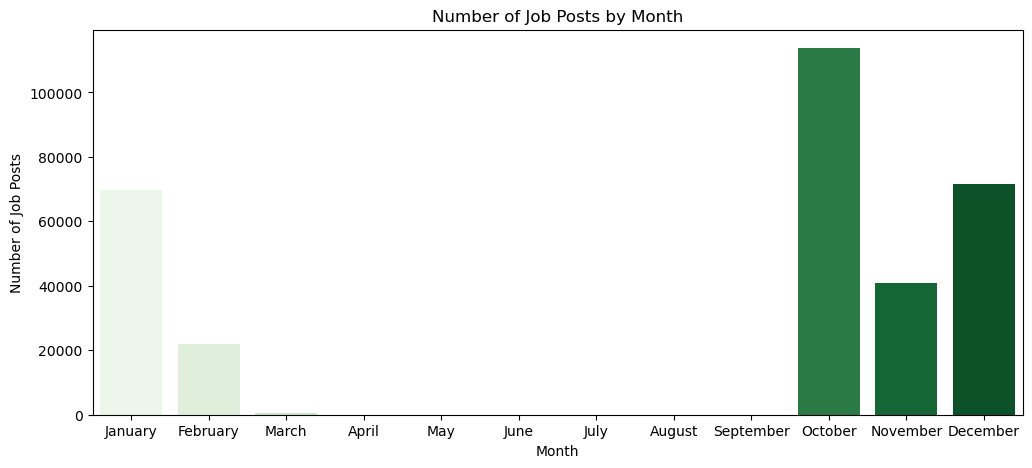

In [53]:
df['Month'] = df['Date'].dt.month_name()
month_counts = df['Month'].value_counts().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])
plt.figure(figsize=(12, 5))
sns.barplot(
    x=month_counts.index,
    y=month_counts.values,
    hue=month_counts.index,
    palette="Greens",
    legend=False
)
plt.title("Number of Job Posts by Month")
plt.xlabel("Month")
plt.ylabel("Number of Job Posts")
plt.show()

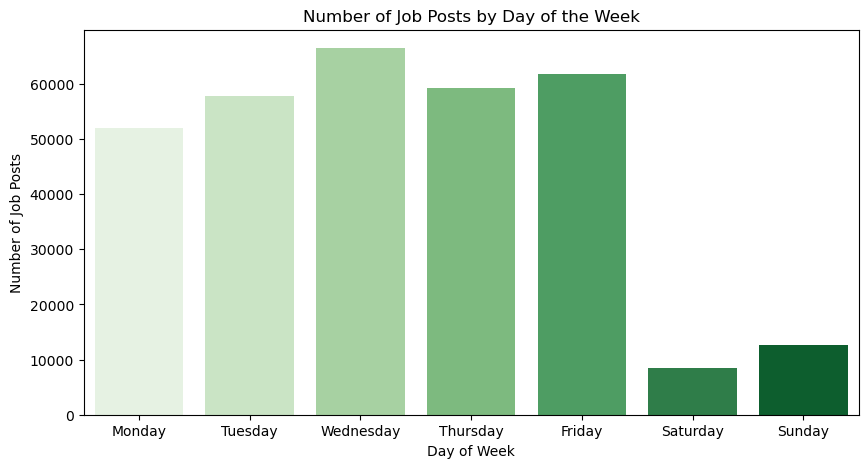

In [55]:
df['DayOfWeek'] = df['Date'].dt.day_name()
day_counts = df['DayOfWeek'].value_counts().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

plt.figure(figsize=(10, 5))
sns.barplot(
    x=day_counts.index,
    y=day_counts.values,
    hue=day_counts.index,
    palette="Greens",
    legend=False
)

plt.title("Number of Job Posts by Day of the Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Job Posts")
plt.show()

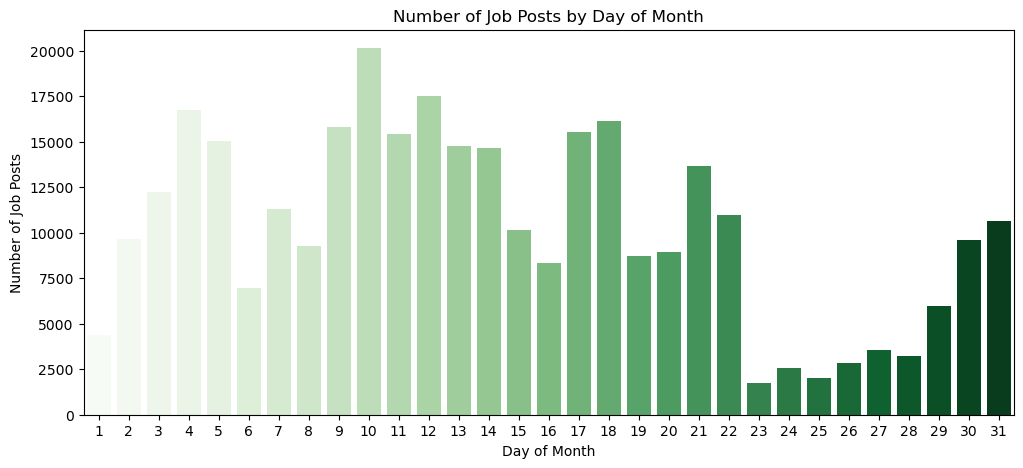

In [56]:
df['DayOfMonth'] = df['Date'].dt.day
day_month_counts = df['DayOfMonth'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.barplot(
    x=day_month_counts.index,
    y=day_month_counts.values,
    hue=day_month_counts.index,
    palette="Greens",
    legend=False
)
plt.title("Number of Job Posts by Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Number of Job Posts")
plt.show()

All the job posts in this data occurs between October to March. This makes sense since in earlier analysis we discovered the data set covers the period October 1st, 2018 to March 13th 2019. Job Posts were most common on mid week especially Wedensdays and with a noticable drop of job posts over the weekend. This aligns with typically business hours and business week. There is a increase in job posting activity during the start and middle of the month and job posting generally decreases toward the end of the month. This may refelct hiring cycles or common posting schedules within companies and organisations.

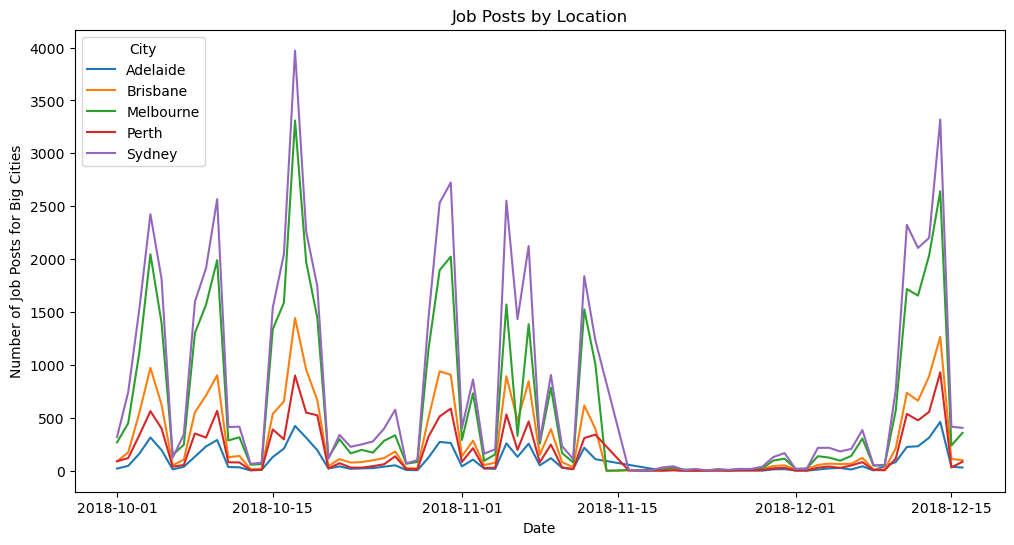

In [57]:
top_cities = ['Sydney', 'Melbourne', 'Brisbane', 'Perth', 'Adelaide']

big_cities_df = df[df['Location'].isin(top_cities)]

trend_data = big_cities_df.groupby(['Date', 'Location']).size().reset_index(name='JobPosts')

plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_data, x='Date', y='JobPosts', hue='Location')
plt.title("Job Posts by Location")
plt.xlabel("Date")
plt.ylabel("Number of Job Posts for Big Cities")
plt.legend(title="City")
plt.show()

The line graph above shows recurring patterns in job postings over time for the 5 major cities. Sydney and Melbourne consistently had the highest amount of job posts with frequent spikes that likely refect weekly and/or monthly hiring schedules. Brisbane followed with average posting activity whilst Perth and Adelaide showed lower and more stable trends in posting. There was also a noticable drop in job postings during late November and early December, possibly due to a holiday period. Overall Sydney and Melbourne dominate the seek job market in terms of posting volume that suggests greater job opportunities in those cities.

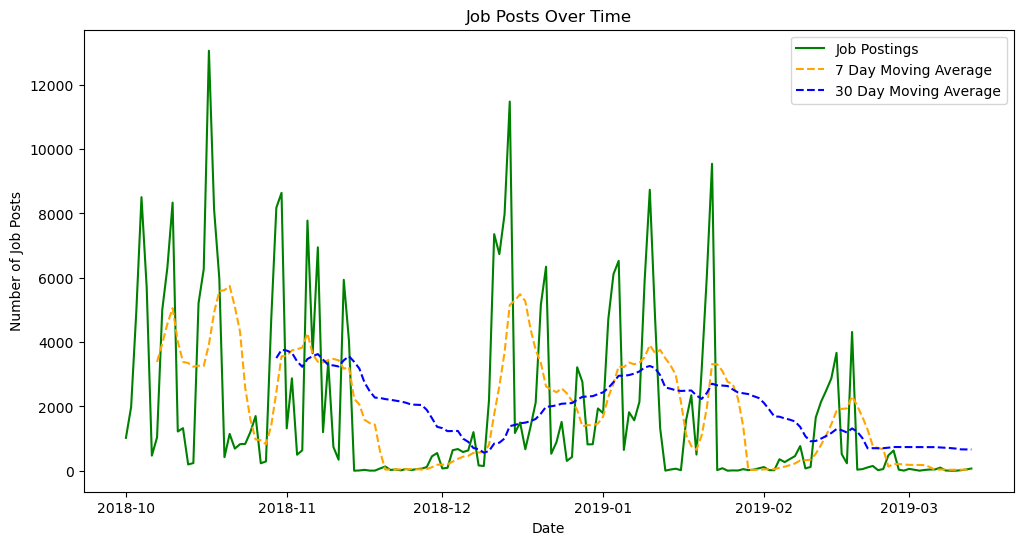

In [58]:
daily_posts = df.groupby('Date').size().reset_index(name='JobPosts')

daily_posts['7DayMA'] = daily_posts['JobPosts'].rolling(window=7).mean()
daily_posts['30DayMA'] = daily_posts['JobPosts'].rolling(window=30).mean()

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_posts, x='Date', y='JobPosts', label='Job Postings', color='green')
sns.lineplot(data=daily_posts, x='Date', y='7DayMA', label='7 Day Moving Average', color='orange',  linestyle='--')
sns.lineplot(data=daily_posts, x='Date', y='30DayMA', label='30 Day Moving Average', color='blue', linestyle='--')

plt.title("Job Posts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Job Posts")
plt.legend()
plt.show()

The 7 day moving average helps detect short term patterns in the job postings like weekly hiring spikes. Although it can be very sensitive for long term analysis. In comparison the 30 day moving average provides a smoother and more reliable trend making it a better choice if the goal is to predict future overall hiring trends.

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from wordcloud import WordCloud

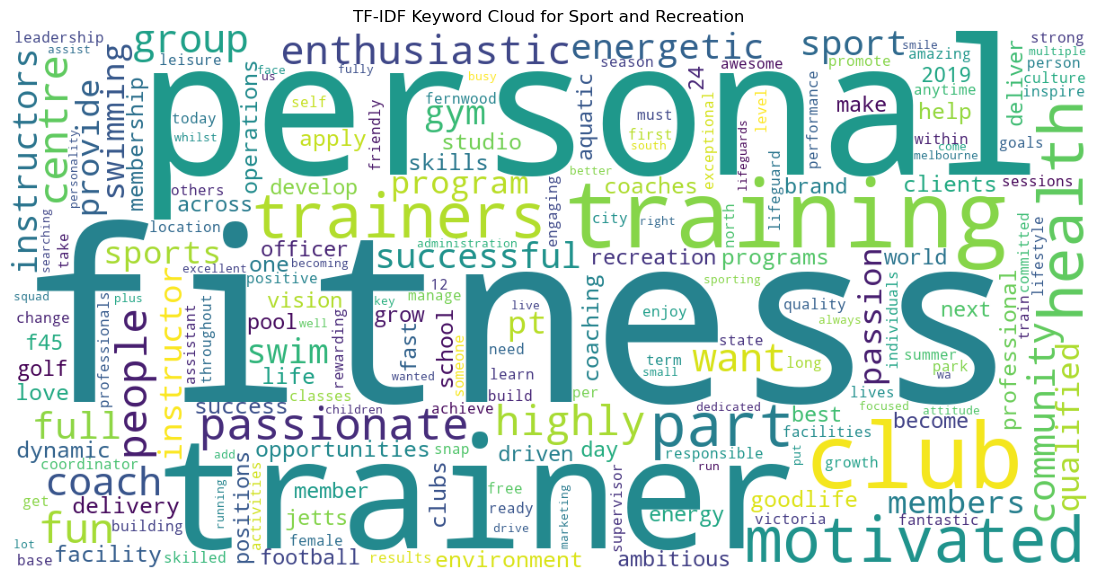

In [62]:
fav_sector = "Sport & Recreation"
subset_df = df[df['Classification'] == fav_sector]['Requirement']

custom_stopwords = [
    'team', 'join', 'opportunity', 'seeking', 'experienced', 'work', 'looking',
    'role', 'time', 'manager', 'business', 'experience', 'exciting', 'great', 
    'based', 'career', 'support', 'company', 'service', 'leading', 'new', 
    'project', 'required', 'start', 'sales', 'services', 'contract', 'currently', 
    'hours', 'position', 'customer', 'sydney', 'week', 'working', 'management', 
    'senior', 'client', 'available', 'casual', 'high', 'projects', 'growing', 
    'australia', 'development', 'permanent', 'care', 'lead', 'industry', 
    'organisation', 'cbd'
]

stop_words = stopwords.words('english') + custom_stopwords

tfidf = TfidfVectorizer(stop_words=stop_words, max_features=200)
tfidf_matrix = tfidf.fit_transform(subset_df)
sum_words = tfidf_matrix.sum(axis=0)

words_freq = {word: sum_words[0, idx] for word, idx in tfidf.vocabulary_.items()}

wordcloud = WordCloud(width=1200, height=600, background_color='white', colormap='viridis')
wordcloud.generate_from_frequencies(words_freq)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title(f"TF-IDF Keyword Cloud for Sport and Recreation")
plt.show()

Part 4 – Discussion

Scenario 1: Tom, a grade 12 student in Brisbane, has good results in all of the
subjects in his school. He is finding a major in the University which can guarantee a
job in his state (Queensland) with a good income (>=80K) in the future. Based on the
current job market dataset, which major and the related subjects do you recommend
him? Explain your choice.***

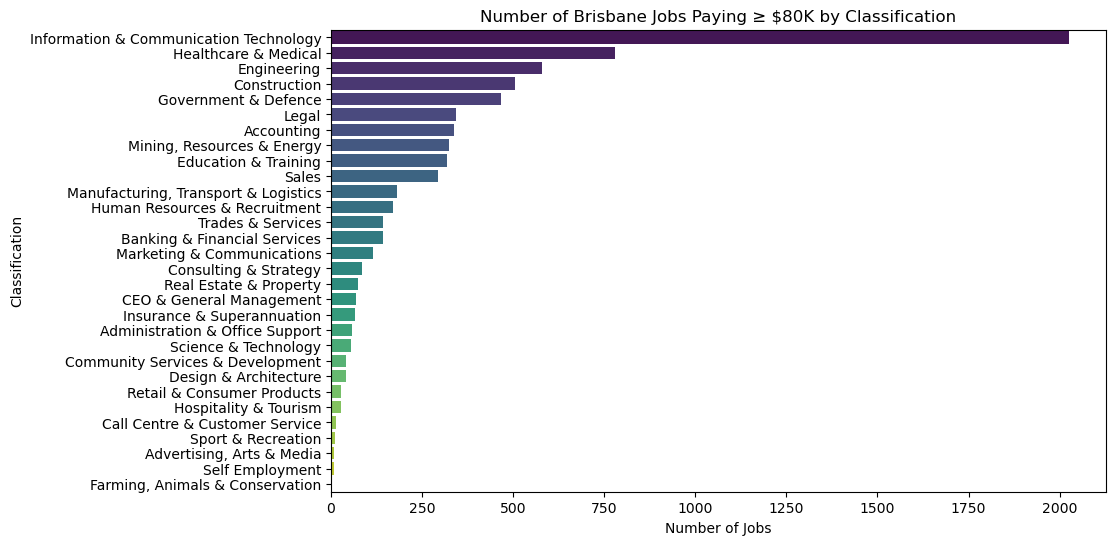

In [64]:
brisbane_highpay = df[(df['Location'] == 'Brisbane') & (df['AverageSalary'] >= 80)]

classification_counts = brisbane_highpay['Classification'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=classification_counts.values,
    y=classification_counts.index,
    hue=classification_counts.index,
    palette="viridis",
    legend=False
)
plt.title('Number of Brisbane Jobs Paying ≥ $80K by Classification')
plt.xlabel('Number of Jobs')
plt.ylabel('Classification')
plt.show()

Since Tom is based in Brisbane, the majority of Queensland Universities are located in Brisbane and majority of the State's population lives in Brisbane i decided to make a Bar Chart of Number of Brisbane Jobs that Pay >=80k by Classifications. Since Tom wants to guarantee a job with good income and Classifictions in this SEEK job market dataset are a good indiction of majors and subjects. The graph above shows that the top high paying sectors in Brisbane are Information & Communication Technology, Healthcare & Medical, Engineering, Cosntruction, Government & Defence. 

Since Tom has good results in all of his subjects i would recommend choosing a major in the Information & Communication Technology Field. For example Computer Science, Data Science, Software Engineering and Cybersecurity. This is not only the highest paying sector by far based on the dataset, but it also offers a wide range of roles across the ICT industy. This sector also has a continued demand predicted in the future due to digitization. 

If Tom prefered a more people oriented field Healthcare & Medical (e.g. Nursing or Medicine) and Government & Defence (e.g. Public Policy or International relations) are also high paying sectors according to dataset with a large number of job posts.

If Tom enjoys subjects such as Maths and physics, Engineering could be highly suitable degree given its a high income job market and offers many majors such as Civil, Mechanical and Electrical.

These majors/degrees also tend to be supported by secure university programs and placements, including Griffith, UQ and QUT which would help Tom transtion from university to employment smoothly. So by aligning his choice of major at University with high paying in demand sectors/Classifications in the Queensland job market Tom can maximise his earning potential after graduation.

Scenario 2: To gain a better reputation, Griffith University wants to attract more
students by enhancing the employability of the graduates. As a data analyst, you
need to give the recommendation for the management board for the changing of the
admission numbers in each major. Which majors should be extended, and which
majors should be reduced (Assume that we only need to use job market data,
regardless of other factors such as social impact, economic impact, etc. )? Justify
your recommendation.*** 

As a data analysist examining the SEEK job market dataset, i have analysed current employment demand across a wide range of classifications to recommend changes to Griffith Unviversity admission mubers for different majors. To improve the Universities employability of graduates and reputation. In Part 2-Data Understanding a bar chart for Number of Jobs by Classification was made, which will help determine the employability of the graduates.ICT, Trades & Services, Healthcare & Medical, Hospitality & Tourism, Maunfacturing, Transport & Logistics, Admin & Office Support were Classificatiosn with high job demand.

Based on this i recommend increasing/extending student intake in majors related to Computer Science, Software Engineering and Data Science (for ICT).Nursing, health and Medicine (for healthcare & medical). Engineering and logistics (for manufacturing & transport). Business Administration (for admin & offcie support). Hospitality Management and Tourism Studies (for  hhospitality & tourism) and any vocational programs related to trades & services offered at the university.

These fields not only show a large volume of job posts but also offer strong average salaries, as seen in previous analyses like the Brisbane salary >=80k bar chart.

Classifications related to university pathways with low job demand suggesting low employement opportunities for graduating students included Advertising, Arts & Media, CEO & General Management, Science & Techonolgy, Farming, Animals & Conservation and Sport & Recreation.

Based on this i recommend decreasing/reducing student intake in majors related to Fine Arts, Media and Journalism (for Advertising & Arts). Generalised Science Degrees (for Science & Technology). Enviromental Science, Agricultural or Animal studies (for Farming, Animals & Conservation). Mangement related degrees/majors (for CEO & General Management). Sport Science (for Sport & Recreation).

This reduction would prevent an oversupply of graduates in fields with fewer job openings helping student focus on higher demand pathways to increase employability.

In Summary Griffth University should use this data informed analysis to stategically increase and decrease admission numbers in the suggested majors to help enhance the employability of graduates and attract more students. Since increasing admissions in high demand classifications increasses job placement and enhances unviersity reputation.